In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Datos_actividad_2.csv')

display(df.head())

,Sucursal,Fecha,Ingresos,Gastos
0,Sucursal1,01/01/2023,12000,8500
1,Sucursal2,01/01/2023,15000,13000
2,Sucursal3,01/01/2023,10000,7500
3,Sucursal4,01/01/2023,9000,6000
4,Sucursal1,01/08/2023,13000,9000


In [8]:
df = pd.read_csv('Datos_actividad_2.csv')

df['Fecha'] = pd.to_datetime(df['Fecha'], format='mixed', dayfirst=True, errors='coerce')

df['Fecha'] = df['Fecha'].ffill() 
df['Mes'] = df['Fecha'].dt.month.astype(int)

df['Ganancia'] = df['Ingresos'] - df['Gastos']
df['Margen %'] = (df['Ganancia'] / df['Ingresos']) * 100

print("Valores nulos por columna:\n", df.isnull().sum())
display(df[['Sucursal', 'Fecha', 'Ingresos', 'Gastos', 'Ganancia', 'Margen %']].head())

Valores nulos por columna:
 Sucursal    0
Fecha       0
Ingresos    0
Gastos      0
Mes         0
Ganancia    0
Margen %    0
dtype: int64


,Sucursal,Fecha,Ingresos,Gastos,Ganancia,Margen %
0,Sucursal1,2023-01-01,12000,8500,3500,29.166667
1,Sucursal2,2023-01-01,15000,13000,2000,13.333333
2,Sucursal3,2023-01-01,10000,7500,2500,25.000000
3,Sucursal4,2023-01-01,9000,6000,3000,33.333333
4,Sucursal1,2023-08-01,13000,9000,4000,30.769231


,Sucursal,Ingresos,Gastos,Ganancia
0,Sucursal1,495000,388000,107000
1,Sucursal2,561000,517000,44000
2,Sucursal3,458320,367500,90820
3,Sucursal4,403500,339630,63870


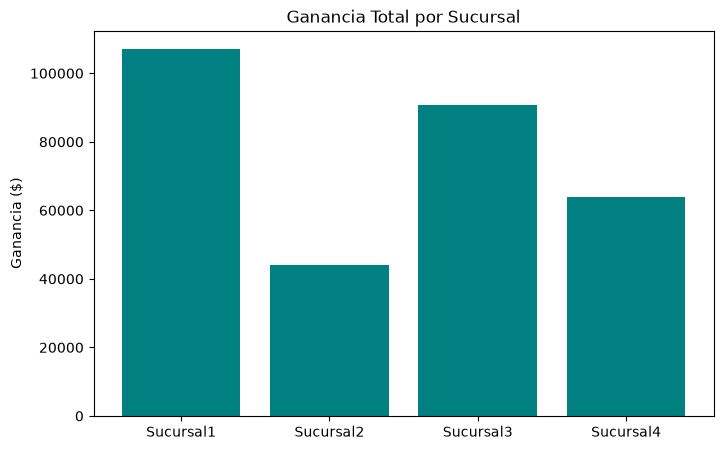

In [10]:
rentabilidad = df.groupby('Sucursal')[['Ingresos', 'Gastos', 'Ganancia']].sum().reset_index()
display(rentabilidad)

plt.figure(figsize=(8,5))
plt.bar(rentabilidad['Sucursal'], rentabilidad['Ganancia'], color='teal')
plt.title('Ganancia Total por Sucursal')
plt.ylabel('Ganancia ($)')
plt.show()

In [ ]:
variabilidad = df.groupby('Sucursal')['Ganancia'].std().reset_index()
variabilidad.rename(columns={'Ganancia': 'Desviación Estándar'}, inplace=True)
display(variabilidad)

,Sucursal,Desviación Estándar
0,Sucursal1,383.648468
1,Sucursal2,0.000000
2,Sucursal3,1675.750397
3,Sucursal4,1200.441928


,Mes,Ingresos,Gastos,Ganancia
0,1,220000,169000,51000
1,2,250000,208000,42000
2,3,191320,153310,38010
3,4,330000,288000,42000
4,5,526000,456000,70000
5,7,92500,83320,9180
6,8,50000,38500,11500
7,9,102000,88000,14000
8,12,156000,128000,28000


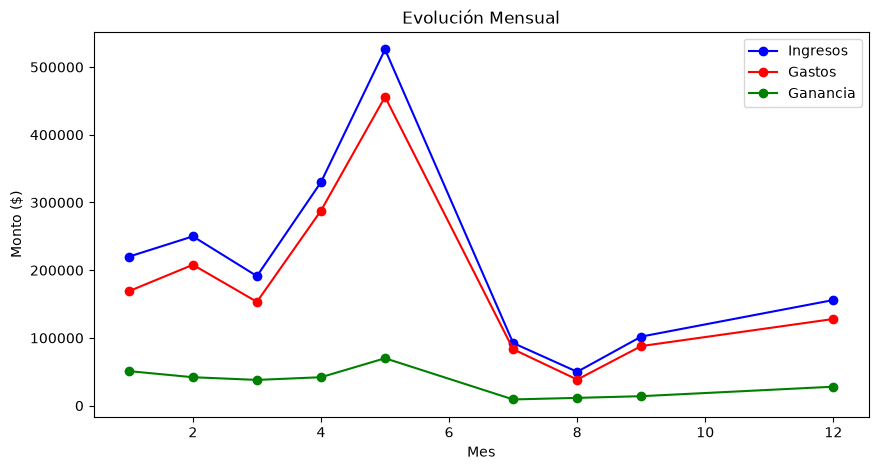

In [ ]:
tendencia = df.groupby('Mes')[['Ingresos', 'Gastos', 'Ganancia']].sum().reset_index()
display(tendencia)

plt.figure(figsize=(10,5))
plt.plot(tendencia['Mes'], tendencia['Ingresos'], marker='o', label='Ingresos', color='blue')
plt.plot(tendencia['Mes'], tendencia['Gastos'], marker='o', label='Gastos', color='red')
plt.plot(tendencia['Mes'], tendencia['Ganancia'], marker='o', label='Ganancia', color='green')
plt.title('Evolución Mensual')
plt.xlabel('Mes')
plt.ylabel('Monto ($)')
plt.legend()
plt.show()

In [ ]:
top_5 = df.nlargest(5, 'Ganancia')
print("--- Top 5 Semanas más rentables ---")
display(top_5[['Sucursal', 'Fecha', 'Ganancia', 'Margen %']])

alertas = df[df['Margen %'] < 15]
alertas.to_csv('Reporte_Alertas.csv', index=False)
print("\n¡Éxito! El archivo 'Reporte_Alertas.csv' se generó correctamente en tu carpeta 'Evidencia 2'.")

--- Top 5 Semanas más rentables ---


,Sucursal,Fecha,Ganancia,Margen %
46,Sucursal3,2023-03-19,11320,39.971751
47,Sucursal4,2023-03-19,5690,28.450000
12,Sucursal1,2023-01-22,5000,33.333333
16,Sucursal1,2023-01-29,5000,31.250000
20,Sucursal1,2023-05-02,5000,29.411765



¡Éxito! El archivo 'Reporte_Alertas.csv' se generó correctamente en tu carpeta 'Evidencia 2'.
